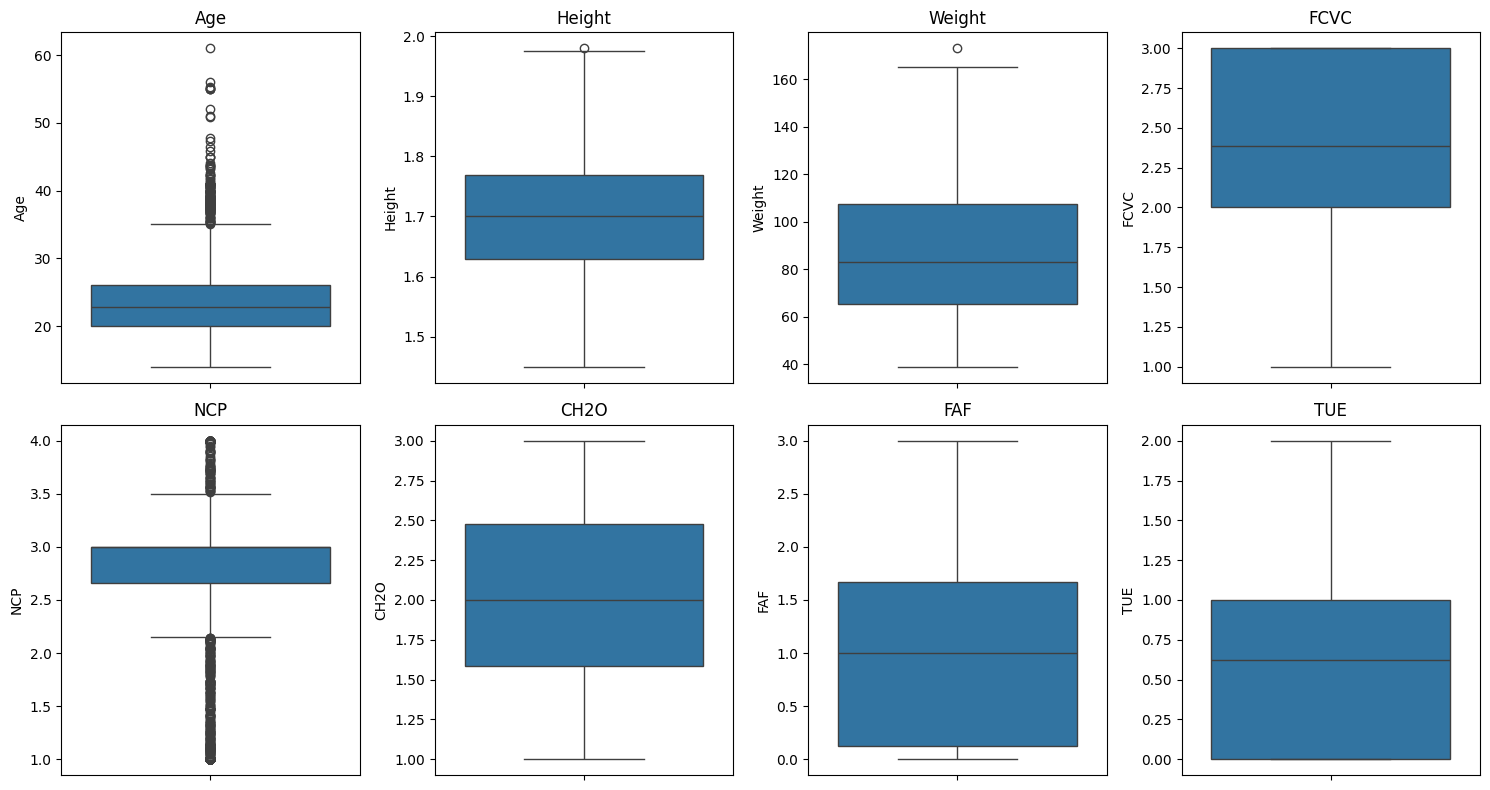

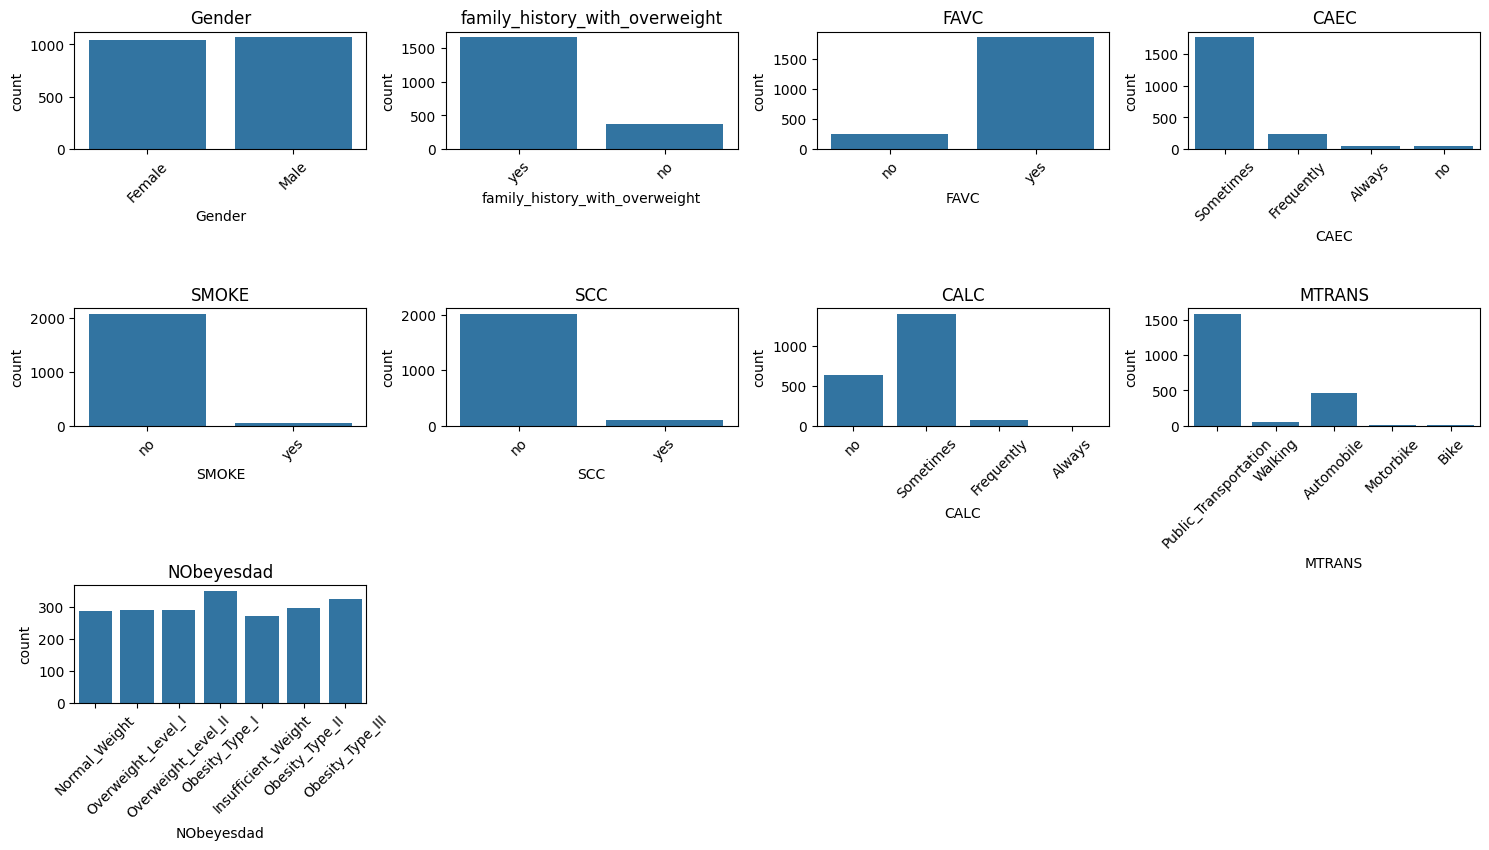

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2038 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF     

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2038,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1663,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN



--- Contoh Data ---


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,NaN,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,NaN,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
#1. Data Understanding
import pandas as pd
import numpy as np

df = pd.read_csv('/content/ObesityDataSet (3).csv')
df_eda = df.copy()

# ==============================
# VISUALISASI OUTLIER (BOXPLOT)
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Ambil hanya kolom numerik
numeric_cols = df_eda.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)  # sesuaikan kalau kolom banyak
    sns.boxplot(y=df_eda[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# ==============================
# COUNTPLOT (KATEGORIKAL)
# ==============================

categorical_cols = df_eda.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=df_eda[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("--- Informasi Dataset ---")
df.info()

print("\n--- Statistik Deskriptif ---")
display(df.describe(include='all'))

print("\n--- Contoh Data ---")
display(df.head())

In [ ]:
#2. Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Menangani Missing Values (Jika ada)
df = df.dropna()

# Encoding Data Kategorikal (Mengubah teks menjadi angka)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Menangani Outlier dengan metode IQR
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Outlier berhasil dihapus dengan metode IQR")

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Standarisasi Data (Penting untuk KNN dan kestabilan GBDT/XGBoost)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing selesai. Data telah di-encode dan di-scale.")

Outlier berhasil dihapus dengan metode IQR
Preprocessing selesai. Data telah di-encode dan di-scale.


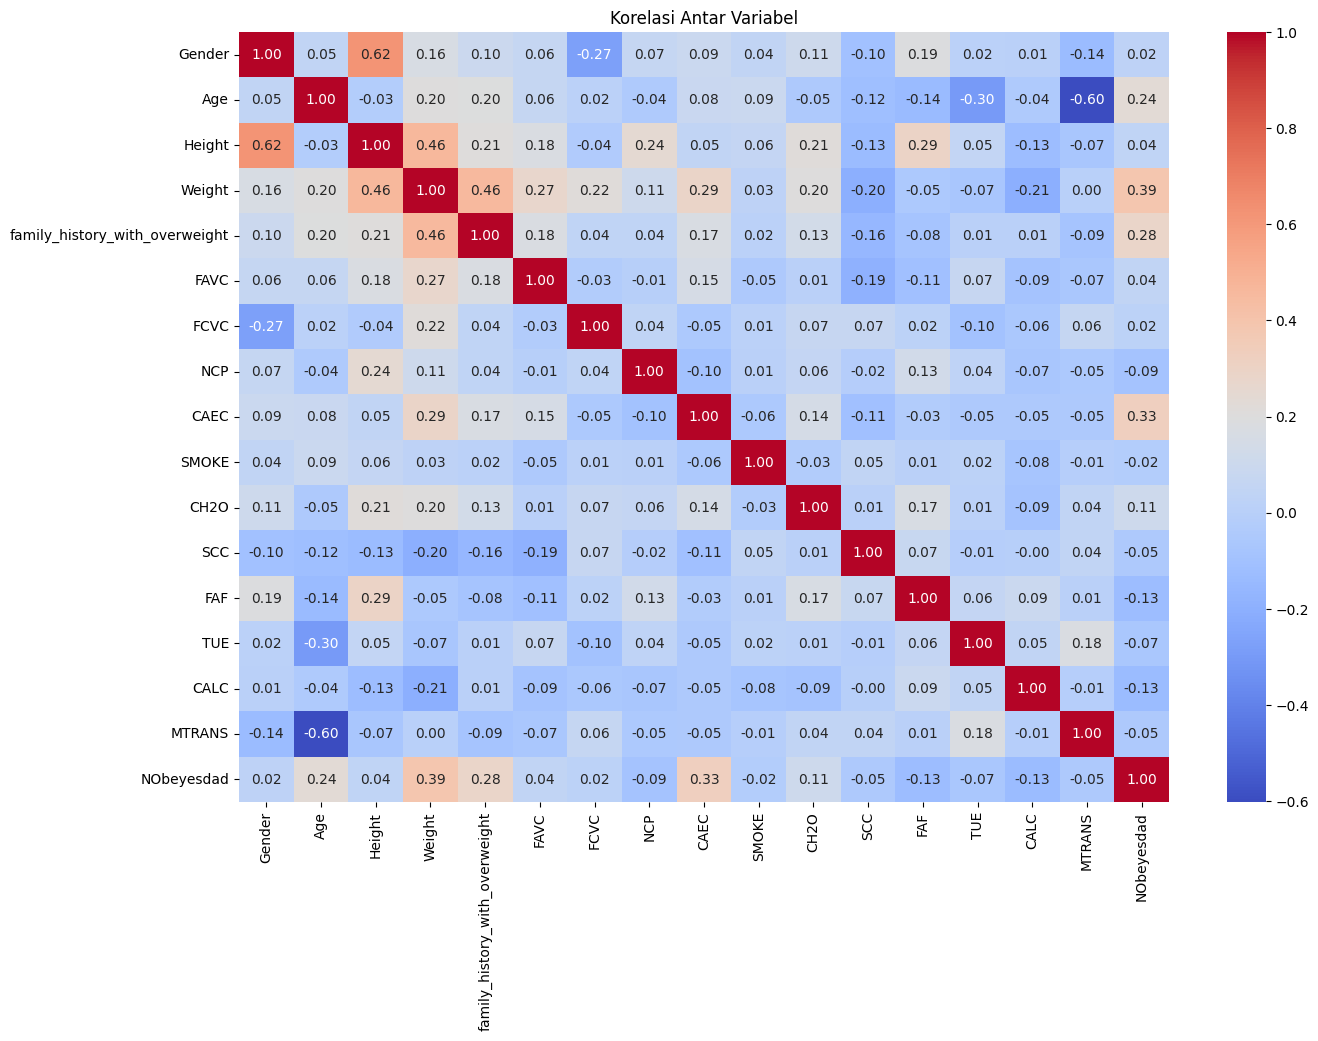

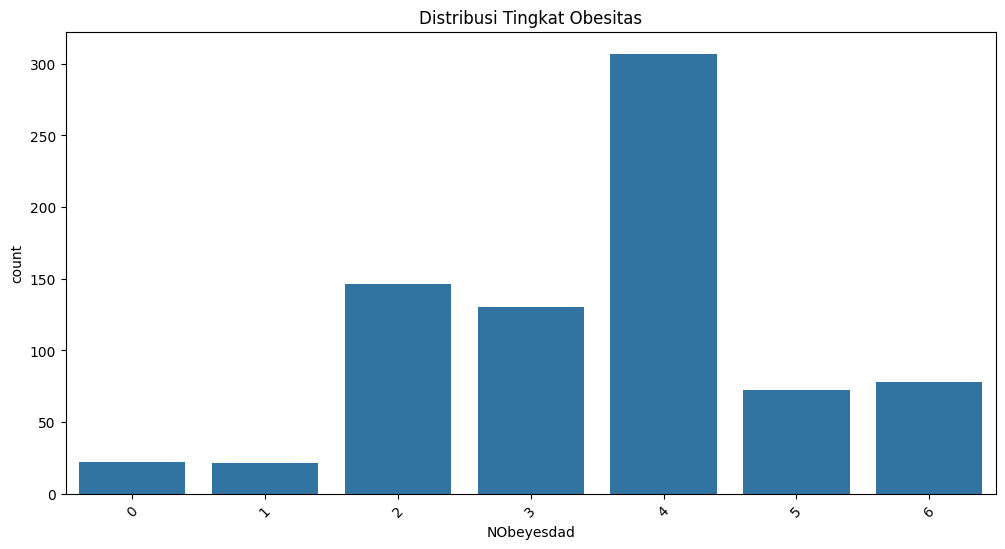

In [ ]:
#3. EDA
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df_eda.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(15, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='NObeyesdad', data=df)
plt.title('Distribusi Tingkat Obesitas')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#4. Data Splitting
from sklearn.model_selection import train_test_split

# Definisi rasio testing (30%, 20%, 10%)
test_sizes = [0.3, 0.2, 0.1]
split_names = ["70:30", "80:20", "90:10"]

print("Variasi splitting data telah disiapkan.")

Variasi splitting data telah disiapkan.


In [ ]:
#5. Model Building
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings

# Menghilangkan peringatan biar output bersih
warnings.filterwarnings('ignore')

# Inisialisasi Model (Tanpa parameter use_label_encoder agar tidak muncul warning)
models = {
    'GBDT': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric='mlogloss'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

all_results = []

# Melakukan 9 Skenario (3 Algoritma x 3 Splitting)
print("Sedang memproses 9 skenario, mohon tunggu sebentar...\n")

for model_name, model in models.items():
    for i, size in enumerate(test_sizes):
        # Splitting
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=size, random_state=42)

        # Training
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Evaluate
        acc = accuracy_score(y_test, y_pred)

        # Simpan hasil
        all_results.append({
            'Algoritma': model_name,
            'Split Ratio': split_names[i],
            'Akurasi (%)': round(acc * 100, 2) # Diubah ke persen agar mudah dibaca
        })

# --- INI BAGIAN UNTUK MENAMPILKAN OUTPUTNYA ---
df_hasil = pd.DataFrame(all_results)

print("="*40)
print("HASIL EVALUASI 9 SKENARIO")
print("="*40)
display(df_hasil) # Ini akan memunculkan tabel cantik di Google Colab
print("="*40)

# Optional: Mencari skenario terbaik secara otomatis
best_scenario = df_hasil.loc[df_hasil['Akurasi (%)'].idxmax()]
print(f"\nSkenario Terbaik: {best_scenario['Algoritma']} dengan Split {best_scenario['Split Ratio']}")
print(f"Akurasi Tertinggi: {best_scenario['Akurasi (%)']}%")

Sedang memproses 9 skenario, mohon tunggu sebentar...

HASIL EVALUASI 9 SKENARIO


,Algoritma,Split Ratio,Akurasi (%)
0,GBDT,70:30,95.28
1,GBDT,80:20,94.23
2,GBDT,90:10,96.15
3,XGBoost,70:30,97.00
4,XGBoost,80:20,96.79
5,XGBoost,90:10,93.59
6,KNN,70:30,88.84
7,KNN,80:20,91.67
8,KNN,90:10,92.31



Skenario Terbaik: XGBoost dengan Split 70:30
Akurasi Tertinggi: 97.0%


In [ ]:
#6. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

print("🔍 Sedang melakukan Hyperparameter Tuning...\n")

# ======================
# 🔵 KNN TUNING
# ======================
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_scaled, y)

print("KNN Best Params:", grid_knn.best_params_)
print("KNN Best Score:", round(grid_knn.best_score_ * 100, 2), "%\n")


# ======================
# 🔵 GBDT TUNING
# ======================
param_grid_gbdt = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gbdt = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid_gbdt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gbdt.fit(X_scaled, y)

print("GBDT Best Params:", grid_gbdt.best_params_)
print("GBDT Best Score:", round(grid_gbdt.best_score_ * 100, 2), "%\n")


# ======================
# 🔵 XGBOOST TUNING
# ======================
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss'),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_scaled, y)

print("XGBoost Best Params:", grid_xgb.best_params_)
print("XGBoost Best Score:", round(grid_xgb.best_score_ * 100, 2), "%\n")


# ======================
# 🔥 SIMPAN MODEL TERBAIK
# ======================
best_models = {
    'GBDT': grid_gbdt.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_,
    'KNN': grid_knn.best_estimator_
}

print("✅ Semua model terbaik sudah siap digunakan!")

🔍 Sedang melakukan Hyperparameter Tuning...

KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
KNN Best Score: 93.95 %

GBDT Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
GBDT Best Score: 96.4 %

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
XGBoost Best Score: 97.17 %

✅ Semua model terbaik sudah siap digunakan!


In [ ]:
#7. Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

all_results = []

# Daftar rasio untuk keperluan looping
test_sizes = [0.3, 0.2, 0.1]
split_names = ["70:30", "80:20", "90:10"]

for algo_name, model in best_models.items():
    for i, size in enumerate(test_sizes):
        # Split Data
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=size, random_state=42)

        # Training
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Hitung Semua Metrik (weighted digunakan karena ini multiclass)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Simpan hasil ke list
        all_results.append({
            'Algoritma': algo_name,
            'Split Ratio': split_names[i],
            'Accuracy (%)': round(acc * 100, 2),
            'Precision (%)': round(prec * 100, 2),
            'Recall (%)': round(rec * 100, 2),
            'F1-Score (%)': round(f1 * 100, 2)
        })

# Tampilkan Tabel
df_hasil_lengkap = pd.DataFrame(all_results)
print("--- TABEL EVALUASI PERFORMA LENGKAP ---")
display(df_hasil_lengkap.sort_values(by=['Algoritma', 'Accuracy (%)'], ascending=[True, False]))

--- TABEL EVALUASI PERFORMA LENGKAP ---


,Algoritma,Split Ratio,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
2,GBDT,90:10,96.15,97.44,96.15,96.76
0,GBDT,70:30,94.85,94.88,94.85,94.85
1,GBDT,80:20,94.23,94.90,94.23,94.42
7,KNN,80:20,94.87,94.90,94.87,94.80
8,KNN,90:10,94.87,94.77,94.87,94.78
6,KNN,70:30,92.70,92.13,92.70,92.31
3,XGBoost,70:30,97.85,97.92,97.85,97.76
4,XGBoost,80:20,96.79,97.22,96.79,96.95
5,XGBoost,90:10,96.15,97.44,96.15,96.76


,Algoritma,Split Ratio,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
3,XGBoost,70:30,97.85,97.92,97.85,97.76
4,XGBoost,80:20,96.79,97.22,96.79,96.95
2,GBDT,90:10,96.15,97.44,96.15,96.76
5,XGBoost,90:10,96.15,97.44,96.15,96.76
8,KNN,90:10,94.87,94.77,94.87,94.78
7,KNN,80:20,94.87,94.90,94.87,94.80
0,GBDT,70:30,94.85,94.88,94.85,94.85
1,GBDT,80:20,94.23,94.90,94.23,94.42
6,KNN,70:30,92.70,92.13,92.70,92.31


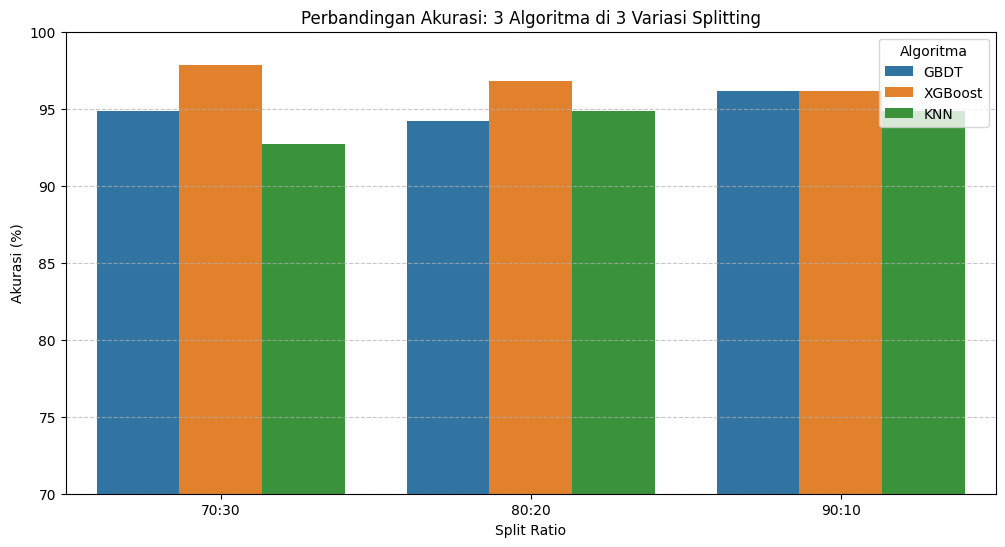

In [ ]:
#8. Model Comparison
# 1. Membuat Tabel Perbandingan
df_comparison = pd.DataFrame(all_results)

# Perhatikan: Nama kolomnya disesuaikan menjadi 'Akurasi (%)'
display(df_comparison.sort_values(by='Accuracy (%)', ascending=False))

# 2. Membuat Grafik Perbandingan
plt.figure(figsize=(12, 6))
# Di sini juga harus diganti menjadi 'Akurasi (%)'
sns.barplot(x='Split Ratio', y='Accuracy (%)', hue='Algoritma', data=df_comparison)

plt.title('Perbandingan Akurasi: 3 Algoritma di 3 Variasi Splitting')
plt.ylim(70, 100) # Karena datanya dalam persen (0-100), limitnya kita ubah ke 70-100
plt.ylabel('Akurasi (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

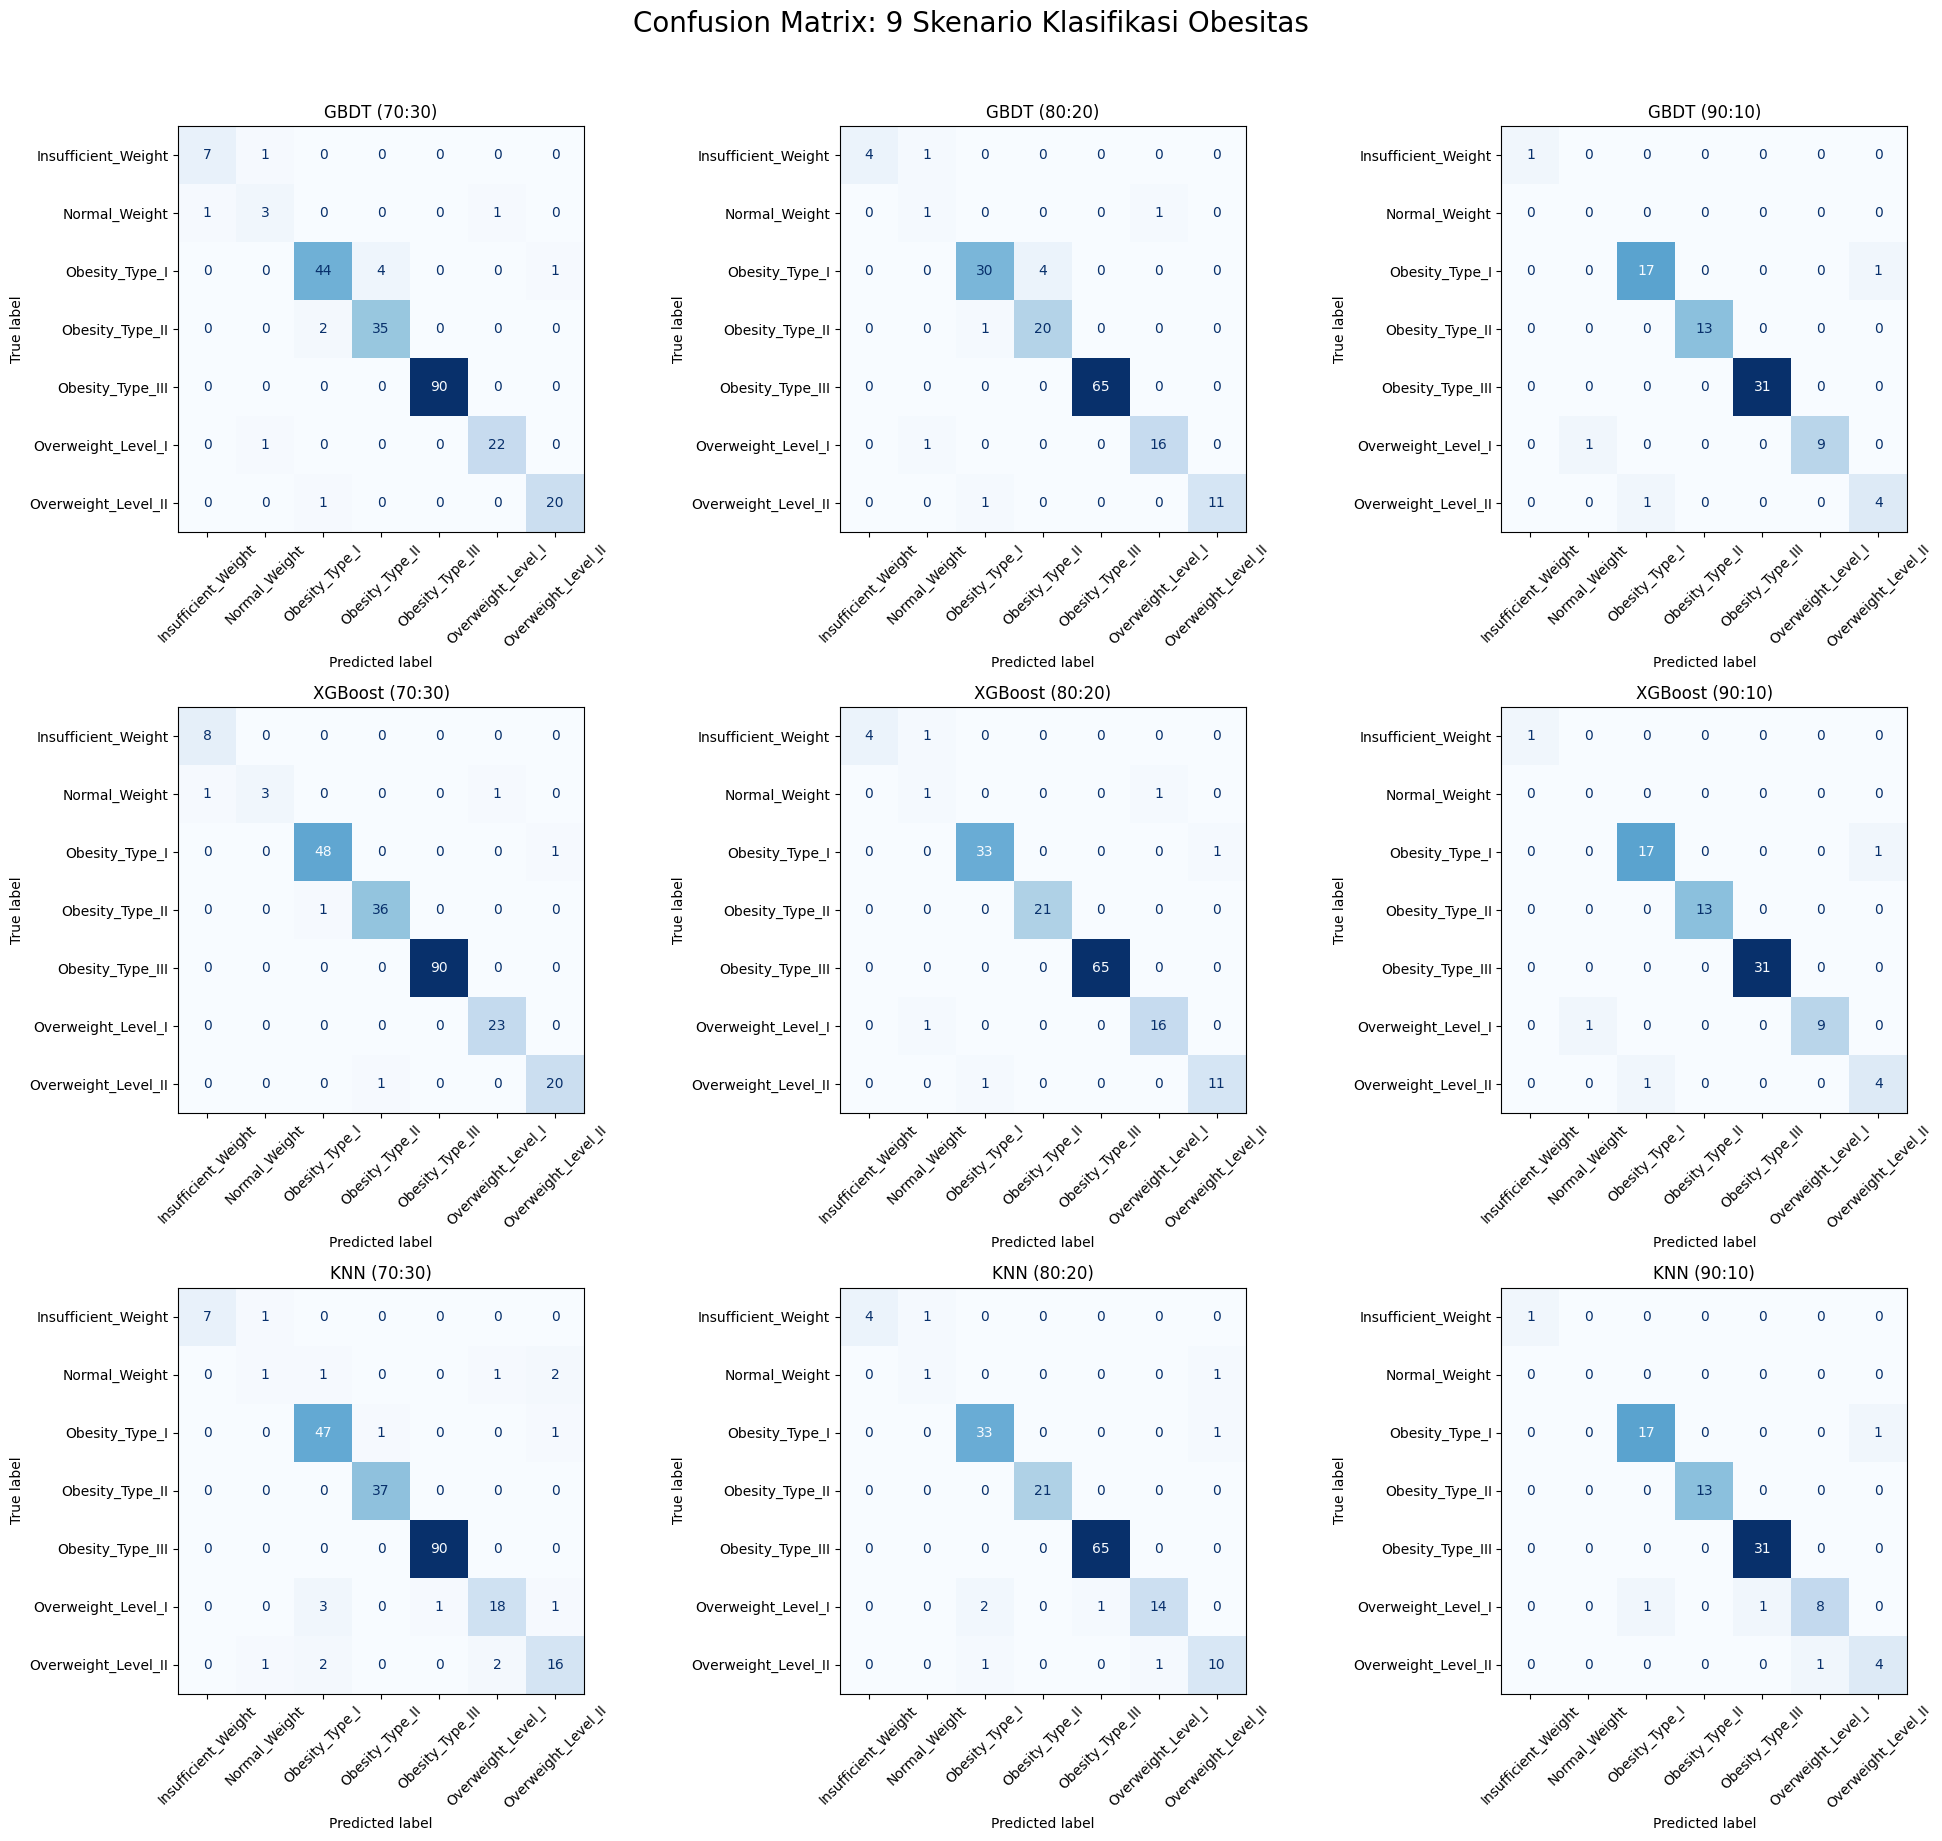

In [ ]:
#9. Visualisasi Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Inisialisasi susunan grafik (3 Baris untuk Algoritma, 3 Kolom untuk Split)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
fig.suptitle('Confusion Matrix: 9 Skenario Klasifikasi Obesitas', fontsize=20, y=1.02)

# Daftar algoritma dan split untuk iterasi
algo_list = ['GBDT', 'XGBoost', 'KNN']
split_list = [0.3, 0.2, 0.1]
split_labels = ["70:30", "80:20", "90:10"]

# Loop untuk menggambar 9 matriks
for row, algo_name in enumerate(algo_list):
    for col, size in enumerate(split_list):
        # 1. Split Data
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=size, random_state=42)

        # 2. Ambil model & Training
        model = best_models[algo_name]
        model.fit(X_train, y_train)

        # 3. Predict
        y_pred = model.predict(X_test)

        # 4. Buat Confusion Matrix
        # Pass all possible labels to ensure consistent matrix shape
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(le.classes_)))

        # 5. Plot ke subplots
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
        disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False, xticks_rotation=45)

        # Set Judul tiap kotak
        axes[row, col].set_title(f"{algo_name} ({split_labels[col]})", fontsize=12)

plt.tight_layout()
plt.show()

Sedang menghitung 5-Fold Cross Validation...

--- HASIL K-FOLD CROSS VALIDATION (K=5) ---


,Algoritma,Mean Accuracy (%),Std Deviation (%),All Scores (%)
0,GBDT,96.27,3.20,"[90.38, 98.06, 95.48, 98.06, 99.35]"
1,XGBoost,97.17,1.12,"[95.51, 96.77, 98.71, 98.06, 96.77]"
2,KNN,93.95,2.08,"[90.38, 96.77, 93.55, 94.19, 94.84]"


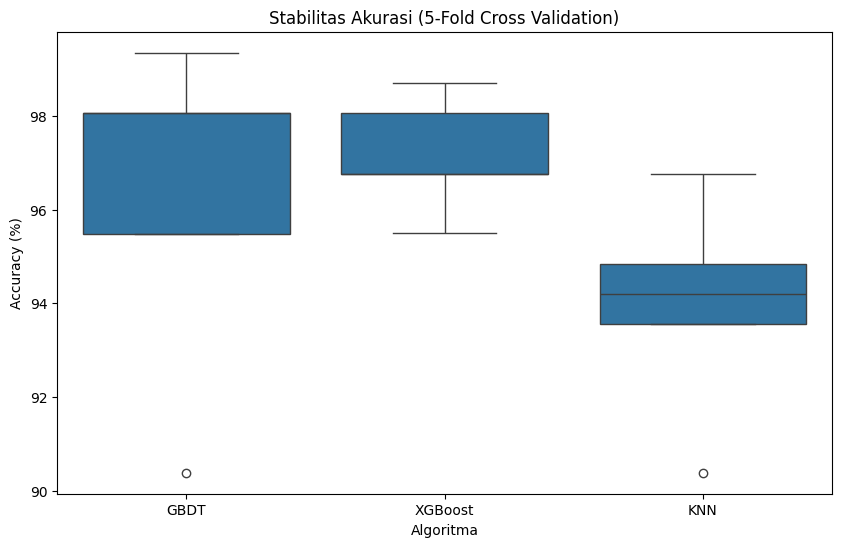

In [ ]:
#10. Cross Validation
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# 1. Inisialisasi list untuk menyimpan hasil CV
cv_results = []

# 2. Kita gunakan K=5 (5-Fold Cross Validation)
# Artinya data akan dibagi 5 bagian dan diuji 5 kali untuk tiap algoritma
k = 5

print(f"Sedang menghitung {k}-Fold Cross Validation...")

for algo_name, model in best_models.items():
    # Melakukan Cross Validation
    # scoring='accuracy' karena ini kasus klasifikasi
    scores = cross_val_score(model, X_scaled, y, cv=k, scoring='accuracy')

    cv_results.append({
        'Algoritma': algo_name,
        'Mean Accuracy (%)': round(scores.mean() * 100, 2),
        'Std Deviation (%)': round(scores.std() * 100, 2),
        'All Scores (%)': [round(s * 100, 2) for s in scores]
    })

# 3. Tampilkan Tabel Hasil
df_cv = pd.DataFrame(cv_results)
print("\n--- HASIL K-FOLD CROSS VALIDATION (K=5) ---")
display(df_cv)

# 4. Visualisasi Boxplot untuk melihat stabilitas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Kita perlu merombak sedikit data untuk boxplot
cv_plot_data = []
for res in cv_results:
    for s in res['All Scores (%)']:
        cv_plot_data.append({'Algoritma': res['Algoritma'], 'Accuracy (%)': s})

df_plot_cv = pd.DataFrame(cv_plot_data)
sns.boxplot(x='Algoritma', y='Accuracy (%)', data=df_plot_cv)
plt.title(f'Stabilitas Akurasi ({k}-Fold Cross Validation)')
plt.show()

In [ ]:

# 11. INFERENCE (PREDIKSI DATA BARU)

# 1. Ambil data baru dari dataset (contoh: 5 data pertama)
data_baru = X.iloc[:20]

# 2. Scaling data (WAJIB pakai scaler yang sama)
data_baru_scaled = scaler.transform(data_baru)—

# 3. Pilih model terbaik (misalnya XGBoost)
model_terbaik = best_models['XGBoost']

# 4. Prediksi
hasil_prediksi = model_terbaik.predict(data_baru_scaled)

# 5. Tampilkan hasil
print("Data Baru:")
display(data_baru)

print("\nHasil Prediksi:")
print(hasil_prediksi)

print("\nLabel Asli (Pembanding):")
print(y.iloc[:20].values)

Data Baru:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
8,1,24.0,1.78,64.0,1,1,3.0,3.0,2,0,2.0,0,1.0,1.0,1,3
9,1,22.0,1.72,68.0,1,1,2.0,3.0,2,0,2.0,0,1.0,1.0,3,3
38,1,23.0,1.65,67.0,1,1,2.0,3.0,2,0,2.0,0,1.0,1.0,2,3
39,0,21.0,1.75,88.0,1,1,2.0,3.0,2,0,3.0,0,3.0,0.0,2,3
40,0,21.0,1.67,75.0,1,1,2.0,3.0,2,0,2.0,0,1.0,0.0,2,3
42,0,21.0,1.66,64.0,1,1,1.0,3.0,2,0,1.0,0,0.0,0.0,3,3
60,0,21.0,1.55,49.0,1,1,2.0,3.0,2,0,3.0,0,3.0,1.0,2,3
77,0,24.0,1.70,80.0,1,1,2.0,3.0,2,0,3.0,0,0.0,0.0,3,3
78,0,23.0,1.65,90.0,1,1,2.0,3.0,2,0,3.0,0,0.0,1.0,3,3
87,1,19.0,1.82,87.0,1,1,2.0,3.0,2,0,2.0,0,0.0,0.0,3,3



Hasil Prediksi:
[1 1 1 6 5 1 1 6 2 5 1 1 1 2 1 1 1 1 1 1]

Label Asli (Pembanding):
[1 1 1 6 5 1 1 6 2 5 1 1 1 2 1 1 1 1 1 1]
